In [1]:
import sys
sys.path.insert(0, '.')

from drug_release_pipeline import (
    load_data, make_splits, verify_splits,
    run_class_xgb_balanced, run_class_rf_balanced, run_class_logistic_balanced,
    compare_class_models, wilcoxon_tests,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import shap
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc

FILE_FORM = 'mp_dataset_processed_no_dupes.xlsx'
FILE_TIME = 'mp_dataset_processed_time_release_only.xlsx'

(X, _, _, y_timepoints, y_auc, y_class, _, _, _, aucs,
 drug_groups, _, _, feature_names) = load_data(FILE_FORM, FILE_TIME)

print(f'X shape          : {X.shape}')
print(f'y_class shape    : {y_class.shape}')
print(f'Burst (AUC>0.5)  : {y_class.sum()} ({100*y_class.mean():.1f}%)')
print(f'Sustained        : {(y_class==0).sum()} ({100*(1-y_class.mean()):.1f}%)')
print(f'Feature names    : {feature_names}')

# Build splits
outer_splits, inner_splits_per_outer = make_splits(drug_groups)
verify_splits(outer_splits, drug_groups)

# Run balanced classification
xgb_res = run_class_xgb_balanced(X, y_class, outer_splits, inner_splits_per_outer, drug_groups)
rf_res  = run_class_rf_balanced(X, y_class, outer_splits, inner_splits_per_outer, drug_groups)
lr_res  = run_class_logistic_balanced(X, y_class, outer_splits, inner_splits_per_outer, drug_groups)

all_results = {
    'XGB'     : xgb_res,
    'RF'      : rf_res,
    'Logistic': lr_res,
}

df_metrics = compare_class_models(all_results)

[verify_splits] OK — 10 folds, 321 formulations, no drug leakage.

===== XGB-Classification-Balanced | OUTER FOLD 1/10 =====
  Test  set class dist : {0: 33, 1: 16}
  Train set class dist : {0: 198, 1: 74}
    [undersample] 198 → 74 majority samples  | total 148 (was 272)


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 11, 'learning_rate': 0.23770102880397392, 'n_estimators': 100, 'subsample': 0.7571172192068059, 'colsample_bytree': 0.7962072844310213, 'gamma': 0.23225206359998862, 'reg_alpha': 0.6075448519014384, 'reg_lambda': 0.17052412368729153}
  ACC=0.6122  ROC-AUC=0.7699  F1=0.5778  Prec=0.4483  Rec=0.8125  Spec=0.5152

===== XGB-Classification-Balanced | OUTER FOLD 2/10 =====
  Test  set class dist : {0: 29, 1: 2}
  Train set class dist : {0: 202, 1: 88}
    [undersample] 202 → 88 majority samples  | total 176 (was 290)


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 9, 'learning_rate': 0.23261153933322942, 'n_estimators': 117, 'subsample': 0.7679536849994257, 'colsample_bytree': 0.7298863974429417, 'gamma': 0.03878841666075722, 'reg_alpha': 0.5007619660898694, 'reg_lambda': 0.6768180580956149}
  ACC=0.4194  ROC-AUC=0.4828  F1=0.1000  Prec=0.0556  Rec=0.5000  Spec=0.4138

===== XGB-Classification-Balanced | OUTER FOLD 3/10 =====
  Test  set class dist : {0: 20, 1: 11}
  Train set class dist : {0: 211, 1: 79}
    [undersample] 211 → 79 majority samples  | total 158 (was 290)


...

  Best params: {'C': 27.29090546829227, 'penalty': 'l2', 'max_iter': 356, 'tol': 1.7988983946554215e-06, 'class_weight': None}
  ACC=0.4000  ROC-AUC=0.4533  F1=0.2500  Prec=0.3333  Rec=0.2000  Spec=0.6000

===== Logistic-Classification-Balanced | OUTER FOLD 9/10 =====
  Test  set class dist : {0: 21, 1: 9}
  Train set class dist : {0: 210, 1: 81}
    [undersample] 210 → 81 majority samples  | total 162 (was 291)


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'C': 0.777223196787316, 'penalty': 'l2', 'max_iter': 497, 'tol': 8.670724410839003e-05, 'class_weight': None}
  ACC=0.7333  ROC-AUC=0.7354  F1=0.6667  Prec=0.5333  Rec=0.8889  Spec=0.6667

===== Logistic-Classification-Balanced | OUTER FOLD 10/10 =====
  Test  set class dist : {0: 19, 1: 11}
  Train set class dist : {0: 212, 1: 79}
    [undersample] 212 → 79 majority samples  | total 158 (was 291)


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'C': 0.007061812489701799, 'penalty': 'l2', 'max_iter': 368, 'tol': 0.0001727530780201236, 'class_weight': 'balanced'}
  ACC=0.4000  ROC-AUC=0.4833  F1=0.3571  Prec=0.2941  Rec=0.4545  Spec=0.3684

[Logistic-Classification-Balanced] Accuracy : 0.5653 ± 0.1515
[Logistic-Classification-Balanced] ROC-AUC  : 0.5771 ± 0.1148
[Logistic-Classification-Balanced] F1       : 0.3903 ± 0.1469
[Logistic-Classification-Balanced] Precision: 0.3353 ± 0.1409
[Logistic-Classification-Balanced] Recall   : 0.5507 ± 0.1997
[Logistic-Classification-Balanced] Specificity: 0.5736 ± 0.2052


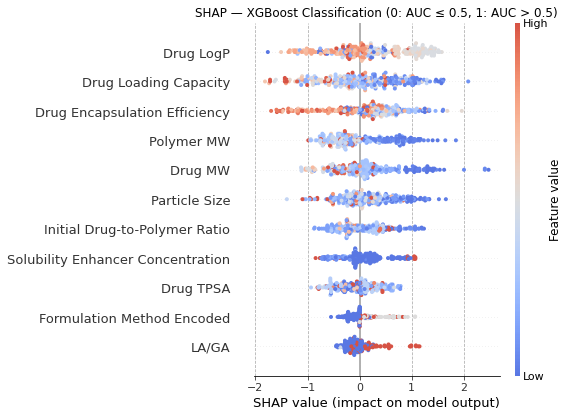

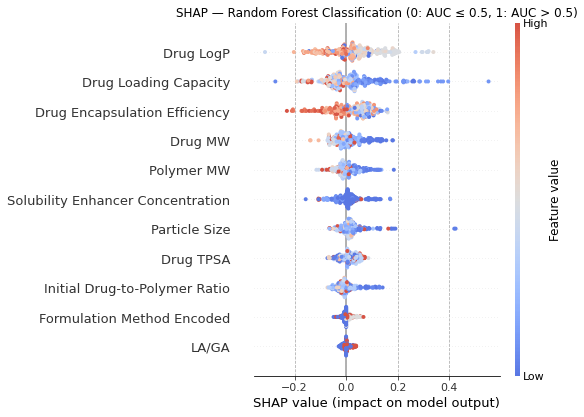

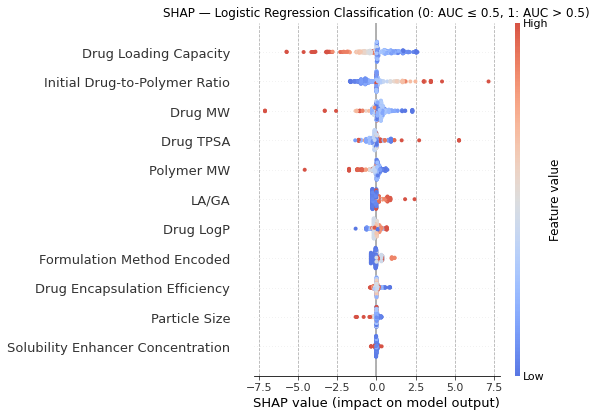

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import shap
from matplotlib.colors import LinearSegmentedColormap

base_cmap  = plt.get_cmap('coolwarm')
light_cmap = LinearSegmentedColormap.from_list(
    'light_coolwarm', base_cmap(np.linspace(0.1, 0.9, 256))
)

def plot_shap_balanced(results, model_label, feature_names, filename=None):
    combined_shap = np.concatenate(
        [sv for sv in results['shap_values'] if sv is not None], axis=0
    )
    combined_X = np.concatenate(results['shap_X_test'], axis=0)

    plt.figure()
    shap.summary_plot(
        combined_shap, combined_X,
        feature_names=feature_names,
        plot_type='dot',
        cmap=light_cmap,
        show=False,
    )
    ax = plt.gca()
    ax.grid(True, which='both', axis='x', linestyle='--')
    ax.set_axisbelow(True)
    plt.title(f'SHAP — {model_label} Classification (0: AUC ≤ 0.5, 1: AUC > 0.5)', fontsize=12)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

plot_shap_balanced(xgb_res, 'XGBoost',             feature_names, 'shap_xgb_classification.png')
plot_shap_balanced(rf_res,  'Random Forest',        feature_names, 'shap_rf_classification.png')
plot_shap_balanced(lr_res,  'Logistic Regression',  feature_names, 'shap_lr_classification.png')


── Wilcoxon p-values (RMSE) ──
                       FC-NN-GRU      FC-NN-LSTM        XGB-Time      XGB-NoTime  XGB-MultiCurve
       FC-NN-GRU              --           0.375           0.375           0.002           0.492
      FC-NN-LSTM           0.375              --           0.322           0.002           0.375
        XGB-Time           0.375           0.322              --           0.002           0.922
      XGB-NoTime           0.002           0.002           0.002              --           0.002
  XGB-MultiCurve           0.492           0.375           0.922           0.002              --

── Wilcoxon p-values (Adj R²) ──
                       FC-NN-GRU      FC-NN-LSTM        XGB-Time      XGB-NoTime  XGB-MultiCurve
       FC-NN-GRU              --           0.275           0.375           0.002           0.492
      FC-NN-LSTM           0.275              --           0.322           0.002           0.322
        XGB-Time           0.375           0.322             

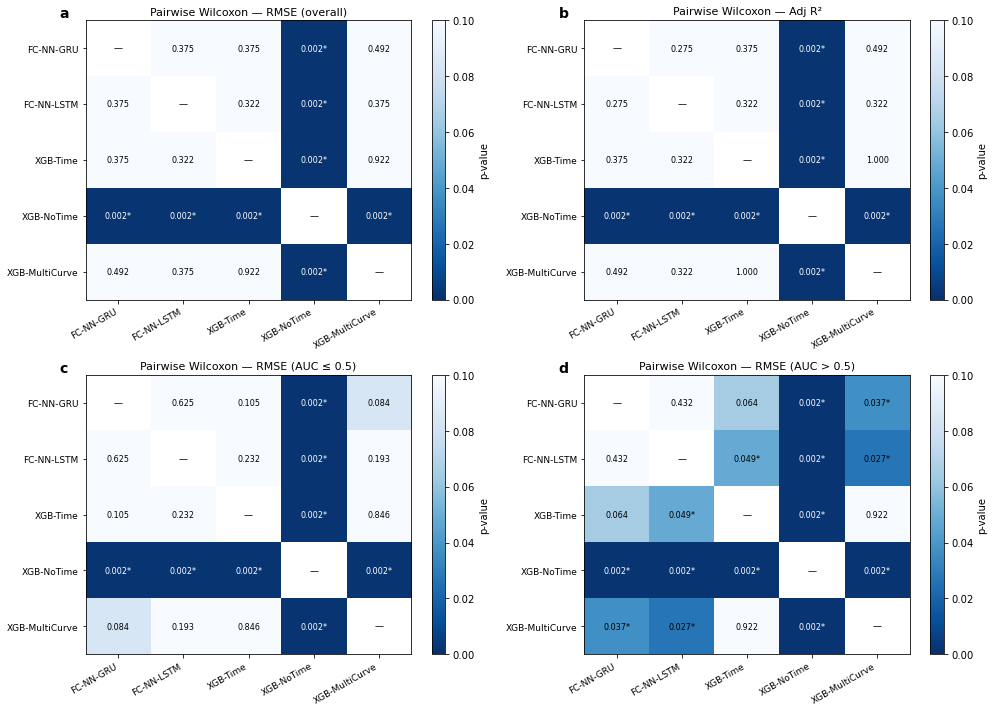

Saved wilcoxon_stats.pdf and wilcoxon_stats.pdf


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon
from itertools import combinations

# ── Per-fold RMSE and Adj R² (extracted from training logs) ───────
data = {
    'FC-NN-GRU': {
        'rmse':      [0.1726, 0.1850, 0.1828, 0.2070, 0.1893, 0.1737, 0.1645, 0.1935, 0.2047, 0.1526],
        'adj_r2':    [0.7171, 0.6975, 0.6126, 0.5705, 0.6162, 0.7021, 0.6933, 0.5899, 0.6157, 0.7223],
        'rmse_low':  [0.2550, 0.2004, 0.1550, 0.1866, 0.2146, 0.1814, 0.1893, 0.1236, 0.2264, 0.1497],
        'rmse_high': [0.1547, 0.1645, 0.1877, 0.2152, 0.1704, 0.1676, 0.1603, 0.1976, 0.1888, 0.1529],
    },
    'FC-NN-LSTM': {
        'rmse':      [0.1683, 0.1762, 0.1863, 0.2250, 0.1862, 0.1834, 0.1657, 0.2005, 0.1985, 0.1676],
        'adj_r2':    [0.7311, 0.7256, 0.5976, 0.4925, 0.6287, 0.6680, 0.6887, 0.5597, 0.6384, 0.6651],
        'rmse_low':  [0.2700, 0.1845, 0.1828, 0.2009, 0.2086, 0.1719, 0.2020, 0.1139, 0.2324, 0.1373],
        'rmse_high': [0.1445, 0.1657, 0.1870, 0.2346, 0.1697, 0.1918, 0.1594, 0.2053, 0.1724, 0.1707],
    },
    'XGB-Time': {
        'rmse':      [0.1718, 0.1902, 0.1601, 0.1734, 0.1777, 0.2095, 0.1848, 0.1623, 0.1899, 0.1464],
        'adj_r2':    [0.7193, 0.6794, 0.7020, 0.6979, 0.6607, 0.5653, 0.6118, 0.7106, 0.6683, 0.7439],
        'rmse_low':  [0.2889, 0.2140, 0.1486, 0.1867, 0.2114, 0.2468, 0.2275, 0.2063, 0.1970, 0.1787],
        'rmse_high': [0.1432, 0.1565, 0.1622, 0.1673, 0.1512, 0.1758, 0.1773, 0.1587, 0.1850, 0.1423],
    },
    'XGB-NoTime': {
        'rmse':      [0.3300, 0.3483, 0.3009, 0.3238, 0.3149, 0.3420, 0.3134, 0.3033, 0.3300, 0.2968],
        'adj_r2':    [-0.0338, -0.0714, -0.0497, -0.0508, -0.0619, -0.1540, -0.1132, -0.0075, 0.0014, -0.0498],
        'rmse_low':  [0.4013, 0.3734, 0.3037, 0.3094, 0.3227, 0.3643, 0.3048, 0.3509, 0.3334, 0.2532],
        'rmse_high': [0.3166, 0.3151, 0.3004, 0.3298, 0.3097, 0.3239, 0.3147, 0.2996, 0.3276, 0.3012],
    },
    'XGB-MultiCurve': {
        'rmse':      [0.1675, 0.2039, 0.1816, 0.1823, 0.1631, 0.1882, 0.1827, 0.1621, 0.1873, 0.1647],
        'adj_r2':    [0.7337, 0.6327, 0.6177, 0.6671, 0.7154, 0.6504, 0.6216, 0.7123, 0.6783, 0.6766],
        'rmse_low':  [0.3056, 0.2377, 0.1764, 0.1748, 0.1946, 0.2293, 0.2266, 0.1398, 0.2145, 0.1543],
        'rmse_high': [0.1310, 0.1531, 0.1826, 0.1854, 0.1381, 0.1493, 0.1750, 0.1635, 0.1667, 0.1658],
    },
}

models    = list(data.keys())
n_models  = len(models)
pairs     = list(combinations(models, 2))

# ── Run paired Wilcoxon tests ──────────────────────────────────────
def run_wilcoxon_matrix(metric):
    pmat = np.ones((n_models, n_models))
    for i, j in combinations(range(n_models), 2):
        a = np.array(data[models[i]][metric])
        b = np.array(data[models[j]][metric])
        _, p = wilcoxon(a, b)
        pmat[i, j] = p
        pmat[j, i] = p
    return pmat

rmse_pmat      = run_wilcoxon_matrix('rmse')
adj_r2_pmat    = run_wilcoxon_matrix('adj_r2')
rmse_low_pmat  = run_wilcoxon_matrix('rmse_low')
rmse_high_pmat = run_wilcoxon_matrix('rmse_high')

# ── Print results ──────────────────────────────────────────────────
for label, pmat in [('RMSE', rmse_pmat), ('Adj R²', adj_r2_pmat),
                    ('RMSE low (AUC≤0.5)', rmse_low_pmat),
                    ('RMSE high (AUC>0.5)', rmse_high_pmat)]:
    print(f'\n── Wilcoxon p-values ({label}) ──')
    header = f"{'':>16}" + ''.join(f'{m:>16}' for m in models)
    print(header)
    for i, mi in enumerate(models):
        row = f'{mi:>16}' + ''.join(
            f'{"--":>16}' if i == j else f'{pmat[i,j]:>16.3f}' for j in range(n_models)
        )
        print(row)

# ── Figure: 2×2 heatmaps ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_pmat(ax, pmat, title):
    display = np.where(np.eye(n_models, dtype=bool), np.nan, pmat)
    cax = ax.imshow(display, cmap='Blues_r', vmin=0, vmax=0.1,
                    aspect='auto', interpolation='nearest')
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(n_models))
    ax.set_yticklabels(models, fontsize=9)
    ax.set_title(title, fontsize=11)
    for i in range(n_models):
        for j in range(n_models):
            if i == j:
                ax.text(j, i, '—', ha='center', va='center', fontsize=9)
            else:
                p = pmat[i, j]
                sig = '*' if p < 0.05 else ''
                txt_color = 'white' if p < 0.02 else 'black'
                ax.text(j, i, f'{p:.3f}{sig}',
                        ha='center', va='center', fontsize=8, color=txt_color)
    plt.colorbar(cax, ax=ax, label='p-value')

plot_pmat(axes[0, 0], rmse_pmat,      'Pairwise Wilcoxon — RMSE (overall)')
plot_pmat(axes[0, 1], adj_r2_pmat,    'Pairwise Wilcoxon — Adj R²')
plot_pmat(axes[1, 0], rmse_low_pmat,  'Pairwise Wilcoxon — RMSE (AUC ≤ 0.5)')
plot_pmat(axes[1, 1], rmse_high_pmat, 'Pairwise Wilcoxon — RMSE (AUC > 0.5)')

for ax, label in zip(axes.flat, ['a', 'b', 'c', 'd']):
    ax.text(-0.08, 1.05, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

#plt.suptitle('Paired Wilcoxon signed-rank tests (per-fold, n=10)\n* p < 0.05',
#             fontsize=12)
plt.tight_layout()
plt.savefig('wilcoxo.pdf', bbox_inches='tight')
#plt.savefig('wilcoxon_stats.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved wilcoxon_stats.pdf and wilcoxon_stats.pdf')

In [9]:
pwd

'/home/cida-lab-2/Karla/Predicting-Drug-Release/Int J Pharm'